In [20]:
import numpy as np
from scipy.stats import gamma
import seaborn as sns
from generating_dataset import dataset,true_beta
from palette import palette
import matplotlib.pyplot as plt
from utils_lasso import standarized_centered_X_y,update_parameters
import matplotlib.ticker as ticker
from sklearn.linear_model import Lasso
import pandas as pd


In [21]:
X,y = dataset
n,p = X.shape[0],X.shape[1]-1
X_stdized,y_tilde = standarized_centered_X_y(X,y)

In [22]:
def bayesian_lasso_hyp(y_tilde, X, r=1.0, delta=0.1, T=11000, B=1000,random_seed=2026):
    """
    Algorithm 3: Bayesian Lasso Gibbs Sampler with lambda hyperprior
    Incorporates the exact t=0 initialization dependency chain.
    """
    np.random.seed(random_seed)
    n, p = X.shape
    
    # Arrays to store the values of each parameter for each iteration
    beta_samples = np.zeros((T, p))
    sigma2_samples = np.zeros(T)
    tau2_samples = np.zeros((T, p))
    lambda_sq_samples = np.zeros(T) 
    
    # Initialisation
    # 1. beta_ols and sigma_ols
    XtX_inv = np.linalg.pinv(X.T @ X)
    beta_curr = XtX_inv @ X.T @ y_tilde
    
    residuals_ols = y_tilde - X @ beta_curr
    
    sigma2_curr = (residuals_ols.T @ residuals_ols) / (n - p - 1)
    
    # 2. Casella lambda initialization
    sum_abs_beta = np.sum(np.abs(beta_curr))
    lambda_curr = (p * np.sqrt(sigma2_curr)) / sum_abs_beta
    lambda_sq_curr = lambda_curr**2
    
    # 3. tau_0 initialisation
    tau2_curr = np.zeros(p)
    for j in range(p):
        beta_j_sq = max(beta_curr[j]**2, 1e-10) # Avoid div by zero
        mu_invgauss = np.sqrt((lambda_sq_curr * sigma2_curr) / beta_j_sq)
        
        inv_tau2_j = np.random.wald(mean=mu_invgauss, scale=lambda_sq_curr)
        tau2_curr[j] = 1.0 / inv_tau2_j

    # =========================================================
    # Gibbs Sampler
    # =========================================================
    for t in range(T):
        
        # 1. Transition Kernel Step 
        beta_curr, sigma2_curr, tau2_curr = update_parameters(
            y_tilde, X, beta_curr, sigma2_curr, tau2_curr, lambda_sq_curr
        )
        
        # 2. Update lambda^2 from Gamma conditional posterior
        shape_param = p + r
        rate_param = 0.5 * np.sum(tau2_curr) + delta
        
        scale_param = 1.0 / rate_param #scale instead of rate
        lambda_sq_curr = gamma.rvs(a=shape_param, scale=scale_param)
        
        # 3. Store the current states
        beta_samples[t, :] = beta_curr
        sigma2_samples[t] = sigma2_curr
        tau2_samples[t, :] = tau2_curr
        lambda_sq_samples[t] = lambda_sq_curr
        
    # Return the post burn-in samples
    return {
        'beta': beta_samples[B:],
        'sigma2': sigma2_samples[B:],
        'tau2': tau2_samples[B:],
        'lambda_sq': lambda_sq_samples[B:]
    }


def bayesian_lasso_em(y_tilde, X, epsilon=1e-6, M=50, K=200, T=11000, B=1000,random_seed=2026):
    np.random.seed(random_seed)
    """
    Algorithm 2: Bayesian Lasso with Pure Monte Carlo EM for lambda
    """
    n, p = X.shape
    
    # Initialisation
    # 1. beta_ols and sigma_ols
    XtX_inv = np.linalg.pinv(X.T @ X)
    beta_curr = XtX_inv @ X.T @ y_tilde
    
    residuals_ols = y_tilde - X @ beta_curr
    sigma2_curr = (residuals_ols.T @ residuals_ols) / (n - p - 1)
    
    # 2. Casella lambda initialisation
    sum_abs_beta = np.sum(np.abs(beta_curr))
    lambda_curr = (p * np.sqrt(sigma2_curr)) / sum_abs_beta
    lambda_sq_curr = lambda_curr**2
    
    # 3. tau_2 initialisation
    tau2_curr = np.zeros(p)
    for j in range(p):
        beta_j_sq = max(beta_curr[j]**2, 1e-10) # Safeguard
        mu_invgauss = np.sqrt((lambda_sq_curr * sigma2_curr) / beta_j_sq)
        inv_tau2_j = np.random.wald(mean=mu_invgauss, scale=lambda_sq_curr)
        tau2_curr[j] = 1.0 / inv_tau2_j

    lambda_history = [lambda_curr]
    
    # -------------------------------
    # Search for the optimal lambda
    # -------------------------------
    for k in range(1, K + 1):
        
        # Array to store the M samples of tau^2 for the expectation
        tau2_samples_E_step = np.zeros((M, p))
        
        # E-Step (Gibbs Sampler for M iterations)
        for m in range(M):
            beta_curr, sigma2_curr, tau2_curr = update_parameters(
                y_tilde, X, beta_curr, sigma2_curr, tau2_curr, lambda_sq_curr
            )
            tau2_samples_E_step[m, :] = tau2_curr
            
        # Calculate Expectation
        E_tau2 = np.mean(tau2_samples_E_step, axis=0)
        
        # M-Step: Update lambda
        lambda_next = np.sqrt((2.0 * p) / np.sum(E_tau2))
        
        # Convergence Check
        if abs(lambda_next - lambda_curr) < epsilon:
            lambda_curr = lambda_next
            lambda_history.append(lambda_curr)
            print(f" -> EM Converged at iteration k={k} to lambda={lambda_curr:.4f}")
            break
            
        lambda_curr = lambda_next
        lambda_sq_curr = lambda_curr**2
        lambda_history.append(lambda_curr)
        

    # Final lambda estimate
    lambda_eb = lambda_curr
    lambda_sq_eb = lambda_eb**2

    # =========================================================
    # Phase 2: Final Gibbs Sampler with fixed lambda
    # =========================================================
    print(f"Starting Phase 2: Posterior Inference (T={T} iterations)...")
    
    # Arrays to store final posterior samples
    beta_samples = np.zeros((T, p))
    sigma2_samples = np.zeros(T)
    tau2_samples = np.zeros((T, p))
    
    
    for t in range(T):
        beta_curr, sigma2_curr, tau2_curr = update_parameters(
            y_tilde, X, beta_curr, sigma2_curr, tau2_curr, lambda_sq_eb
        )
        
        beta_samples[t, :] = beta_curr
        sigma2_samples[t] = sigma2_curr
        tau2_samples[t, :] = tau2_curr

    # Return post burn-in samples
    return {
        'lambda_EB': lambda_eb,
        'lambda_history': np.array(lambda_history),
        'beta_samples': beta_samples[B:],   
        'sigma2_samples': sigma2_samples[B:],
        'tau2_samples': tau2_samples[B:]
    }

### Calculate lambda_0

In [23]:
# 1. OLS Initialization using STANDARDIZED X and CENTERED y
XtX_inv = np.linalg.pinv(X_stdized.T @ X_stdized)
beta_curr = XtX_inv @ X_stdized.T @ y_tilde

residuals_ols = y_tilde - X_stdized @ beta_curr
sigma2_curr = (residuals_ols.T @ residuals_ols) / (n - p - 1)

# 2. Casella lambda initialization
sum_abs_beta = np.sum(np.abs(beta_curr))
lambda_curr = (p * np.sqrt(sigma2_curr)) / sum_abs_beta
lambda_sq_curr = lambda_curr**2

### <b> Run both methods

In [24]:
lambda_0 = np.sqrt(lambda_sq_curr)
results_hyp = bayesian_lasso_hyp(y_tilde,X_stdized,r=1,delta=0.1,T=11000,B=1000)

In [25]:
results_eb = bayesian_lasso_em(y_tilde, X_stdized,epsilon=1e-3, M=1000, K=100, T=11000, B=1000)

 -> EM Converged at iteration k=8 to lambda=2.5463
Starting Phase 2: Posterior Inference (T=11000 iterations)...


### Calculate estimated_sigma^2 for last graphic

In [26]:
estimated_sigma2=np.mean(results_eb["sigma2_samples"])
estimated_sigma2

6.55567090071032

### <b> Coefficients distributions

In [27]:
beta_samples_hyp = results_hyp["beta"]
beta_samples_eb = results_eb["beta_samples"]

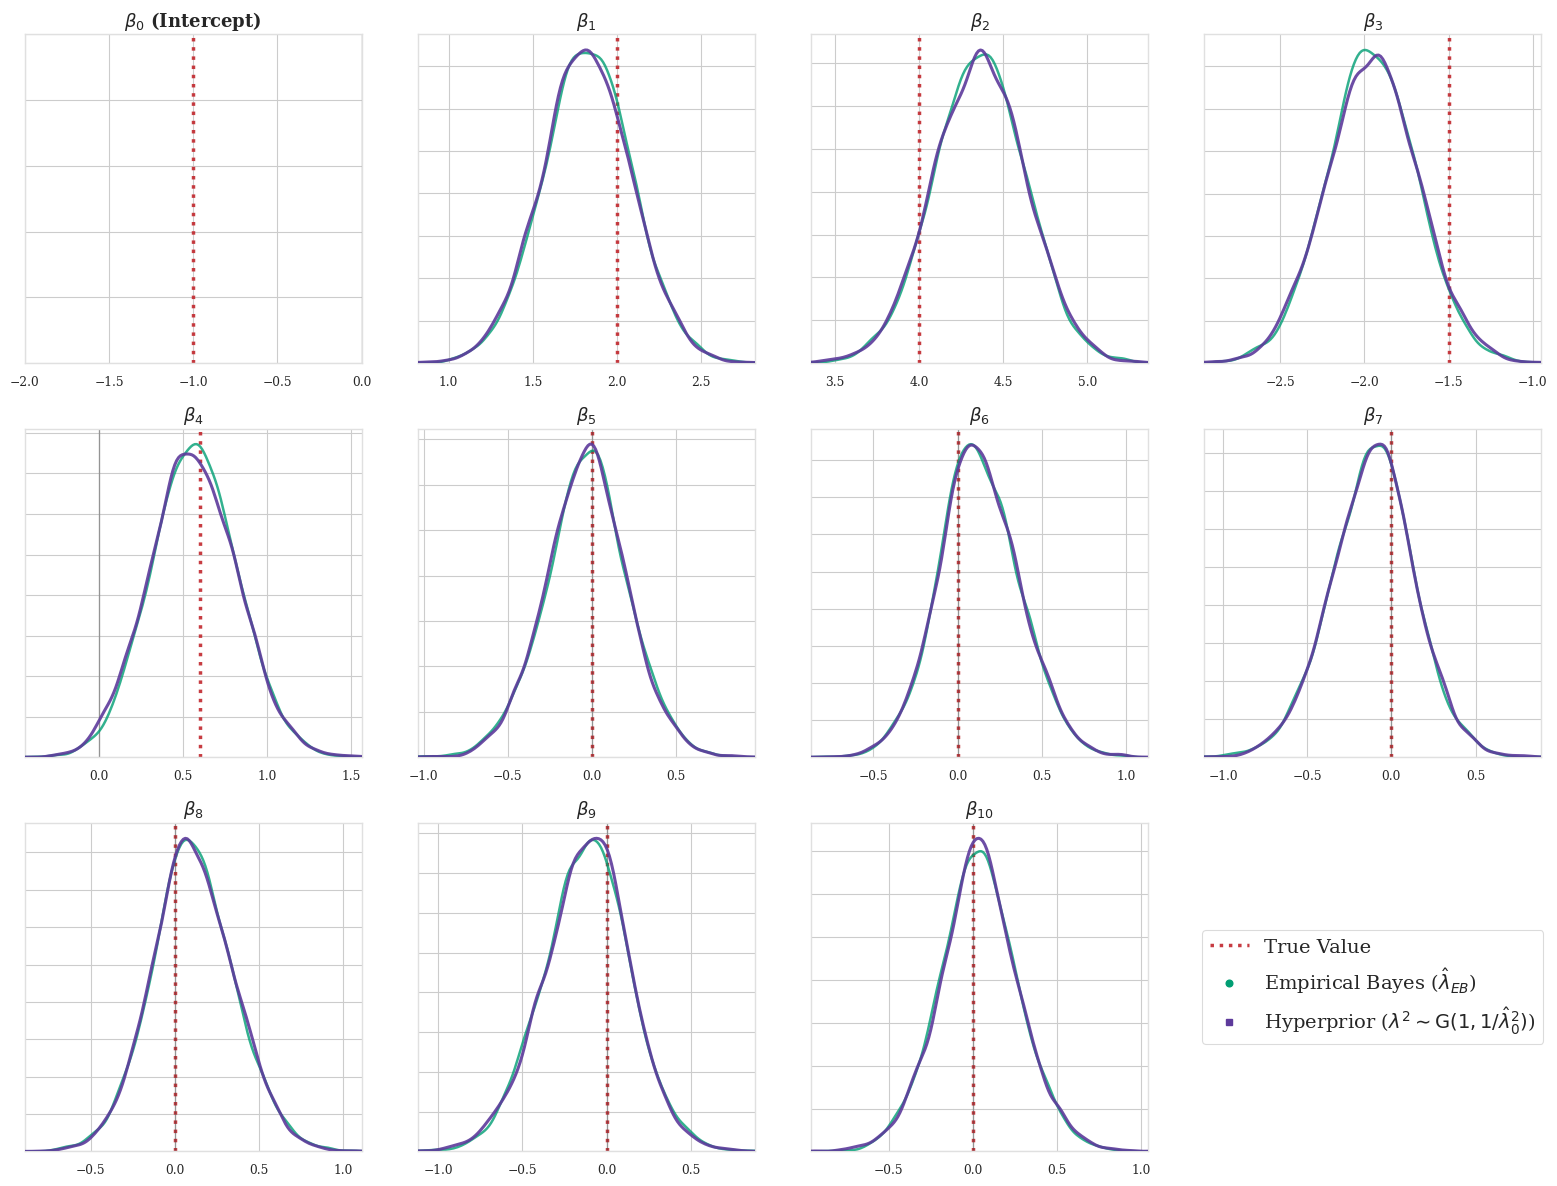

In [28]:
sns.set_theme(style="whitegrid", context="paper", font="serif")
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold'})
grid_gray = "#E0E0E0" 


window_radius = 1.0  #(center - 1, center + 1)
num_vars = beta_samples_hyp.shape[1] 

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
axes = axes.flatten()

# ==============================================================================
# PLOT
# ==============================================================================
for i in range(num_vars + 1):
    ax = axes[i]
    
    if i == 0:
        true_val = true_beta[0]
        samples_eb = np.array([])
        samples_hyp = np.array([])
        titulo = r"$\boldsymbol{\beta_{0}}$ (Intercept)"
    else:
        true_val = true_beta[i]
        samples_eb = beta_samples_eb[:, i-1]
        samples_hyp = beta_samples_hyp[:, i-1]
        titulo = rf"$\boldsymbol{{\beta_{{{i}}}}}$"

    # Hyperprior mean
    current_center = np.mean(samples_hyp) if len(samples_hyp) > 0 else true_val

    # True value
    ax.axvline(true_val, color=palette.true_red, linestyle=':', linewidth=2.5, 
                alpha=0.9, zorder=1, label='True Value')
    ax.axvline(0, color=palette.zero_gray, linestyle='-', alpha=0.4, linewidth=1, zorder=2)

    # EB approach
    if len(samples_eb) > 0:
        ax.errorbar([], [], fmt='o', color=palette.lasso_em, label=r'Empirical Bayes ($\hat\lambda_{EB}$)') 
        sns.kdeplot(samples_eb, ax=ax, color=palette.lasso_em, linewidth=1.8, 
                    fill=False, alpha=0.8, zorder=3)

    # Hyperprior approach
    if len(samples_hyp) > 0:
        label_hyp = r'Hyperprior ($\lambda^2 \sim \text{G}(1, 1/\hat{\lambda}_0^2)$)'
        ax.errorbar([], [], fmt='s', color=palette.lasso_hyp, label=label_hyp) 
        sns.kdeplot(samples_hyp, ax=ax, color=palette.lasso_hyp, linewidth=2.2, 
                    fill=False, alpha=0.9, zorder=4)

  
    ax.set_xlim(current_center - window_radius, current_center + window_radius)
    
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    
    ax.set_title(titulo, fontsize=13)
    ax.set_ylim(bottom=0)
    ax.set_ylabel('')  
    ax.tick_params(axis='y', labelleft=False)
    

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(grid_gray)
        spine.set_linewidth(1.0)

# Legend setup
for j in range(num_vars + 1, len(axes)):
    axes[j].axis('off')
    if j == len(axes) - 1:
        handles, labels = axes[1].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        axes[j].legend(by_label.values(), by_label.keys(), loc='center', 
                        fontsize=14, frameon=True, edgecolor='#D3D3D3', facecolor='white')

plt.tight_layout()
plt.savefig("../graphics/posteriors_lasso.pdf")
plt.show()


### <b> Credible intervals for both approaches

In [29]:
def get_stats(samples):
    # Estimate
    medians = np.median(samples, axis=0)
    
    lower = np.percentile(samples, 2.5, axis=0)
    upper = np.percentile(samples, 97.5, axis=0)
    
    errors = np.array([medians - lower, upper - medians])
    return medians, errors

# Empirical Bayes
mean_eb, err_eb = get_stats(results_eb['beta_samples'])

# Hyperprior
mean_hyp, err_hyp = get_stats(results_hyp['beta'])

# True values of coefficients
true_values = true_beta[1:] if len(true_beta) > 10 else true_beta

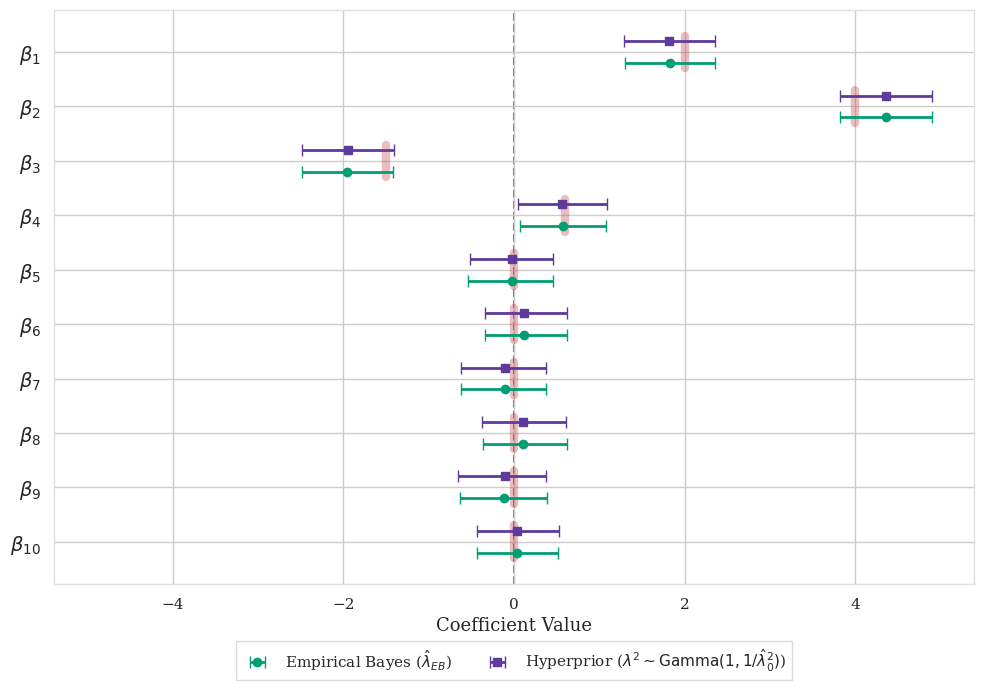

In [30]:
sns.set_theme(style="whitegrid", font="serif")
fig, ax = plt.subplots(figsize=(10, 7))


p = mean_eb.shape[0] 
y_pos = np.arange(p)
offset = 0.2  

# A. True value
for i in range(p):
    ax.plot([true_values[i], true_values[i]], [y_pos[i]-0.3, y_pos[i]+0.3], 
            color=palette.true_red, alpha=0.3, linewidth=6, zorder=1)

# B. Empirical Bayes
ax.errorbar(mean_eb, y_pos + offset, xerr=err_eb, fmt='o', 
            color=palette.lasso_em, linewidth=2, capsize=4, 
            label='Empirical Bayes ($\hat\lambda_{EB}$)')

# C. Hyperprior
ax.errorbar(mean_hyp, y_pos - offset, xerr=err_hyp, fmt='s', 
            color=palette.lasso_hyp, linewidth=2, capsize=4, 
            label=r'Hyperprior ($\lambda^2 \sim \text{Gamma}(1, 1/\hat{\lambda}_0^2)$)')

# zero
ax.axvline(0, color=palette.zero_gray, linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


all_values = np.concatenate([mean_eb + err_eb[1], mean_eb - err_eb[0], 
                             mean_hyp + err_hyp[1], mean_hyp - err_hyp[0],
                             true_values])
max_abs = np.max(np.abs(all_values))
padding = 1.1 
ax.set_xlim(-max_abs * padding, max_abs * padding)


for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(grid_gray) 
    spine.set_linewidth(1.0)


ax.set_yticks(y_pos)
ax.set_yticklabels([f"$\\boldsymbol{{\\beta_{{{i+1}}}}}$" for i in range(p)], fontsize=14)
ax.invert_yaxis() 

ax.set_xlabel("Coefficient Value", fontsize=13)

# Legend setup
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=11, 
           frameon=True, edgecolor='#D3D3D3', fancybox=False)

plt.tight_layout()
plt.savefig("../graphics/bayesian_lasso_ci.pdf")
plt.show()

### <B> Malick Mixed appraoch

In [31]:
lambda_eb = results_eb["lambda_EB"]
lambda_eb

2.5462632386148574

In [32]:
# Estimation instead of the true (but unknown) value
sigma_sample = np.sqrt(estimated_sigma2)

# --- 2. Experiment Parameters ---
n = 100
lambda_bayesian_em = 2.56  # Lambda value obtained by Empirical Bayes

alpha_scaled = (lambda_bayesian_em * sigma_sample) / n

print(f"Mixed Approach Configuration:")
print(f"  > Estimated sigma (sqrt(estimated_sigma2)): {sigma_sample:.4f}")
print(f"  > Scaled alpha for sklearn: {alpha_scaled:.5f}\n")

# Standardize data
y_tilde = y - np.mean(y)
X_stdized = X[:, 1:]

# Run Lasso
lasso_mixed = Lasso(alpha=alpha_scaled, fit_intercept=False, max_iter=10000)
lasso_mixed.fit(X_stdized, y_tilde)

# Sparsity analysis
coefficients = lasso_mixed.coef_
true_betas = [2.0, 4.0, -1.5, 0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

df_comparison = pd.DataFrame({
    'Variable': [f'Beta_{i+1}' for i in range(len(coefficients))],
    'True Value': true_betas,
    'Mixed Estimate': coefficients,
    'Status': ['Relevant' if abs(v) > 1e-10 else 'COLLAPSED TO ZERO' for v in coefficients]
})

print("--- FINAL RESULTS: MIXED APPROACH ---")
print(df_comparison)

# Summary of discarded variables
discarded_variables = np.where(np.abs(coefficients) < 1e-10)[0] + 1
print(f"\nVariables discarded by the model (coefficient = 0): {discarded_variables.tolist()}")

Mixed Approach Configuration:
  > Estimated sigma (sqrt(estimated_sigma2)): 2.5604
  > Scaled alpha for sklearn: 0.06555

--- FINAL RESULTS: MIXED APPROACH ---
  Variable  True Value  Mixed Estimate             Status
0   Beta_1         2.0        1.827147           Relevant
1   Beta_2         4.0        4.392602           Relevant
2   Beta_3        -1.5       -1.922575           Relevant
3   Beta_4         0.6        0.550348           Relevant
4   Beta_5         0.0       -0.000000  COLLAPSED TO ZERO
5   Beta_6         0.0        0.071027           Relevant
6   Beta_7         0.0       -0.038851           Relevant
7   Beta_8         0.0        0.065945           Relevant
8   Beta_9         0.0       -0.061957           Relevant
9  Beta_10         0.0        0.000000  COLLAPSED TO ZERO

Variables discarded by the model (coefficient = 0): [5, 10]
